Multiple linear regression in Python

In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [2]:
data = {
    "Study_Hours" : [2, 3, 4, 5, 6, 7, 8, 9],
    "Attendance"  : [60, 65, 70, 75, 80, 85, 90, 95],
    "Assignment_Score" : [50, 55, 58, 65, 70, 74, 80, 88],
    "Final_Marks" : [42, 48, 54, 61, 67, 73, 81, 89]
}

df = pd.DataFrame(data)

In [3]:
x = df[["Study_Hours","Attendance","Assignment_Score"]]
y = df["Final_Marks"]

In [4]:
model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)

print("Intercept : ", model.intercept_)

Intercept :  -28.31652806652808


In [5]:
coefficient_table = pd.DataFrame({
    "Feature" : x.columns,
    "Coefficient" : model.coef_
})

In [6]:
print(coefficient_table)

            Feature  Coefficient
0       Study_Hours     0.131410
1        Attendance     0.657051
2  Assignment_Score     0.608108


In [7]:
new_student = pd.DataFrame({
    "Study_Hours" : [6],
    "Attendance" : [82],
    "Assignment_Score" : [72]
})

In [8]:
prediction = model.predict(new_student)

print("Predicted final mark : ", prediction[0])

Predicted final mark :  70.13392238392238


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [10]:
model_test = LinearRegression()
model_test.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_test_pred = model_test.predict(x_test)

In [12]:
print("Intercept : ", model.intercept_)
print("Slope : ", model.coef_[0])
print("Actual values : ", y_test.values)
print("Predicted values : ", y_pred)

Intercept :  -28.31652806652808
Slope :  0.13141025641025642
Actual values :  [48 73]
Predicted values :  [41.77477477 48.23198198 53.47297297 61.1463964  67.6036036  73.4527027
 80.51801802 88.79954955]


In [14]:
print("MAE       : ", mean_absolute_error(y_test, y_test_pred))
print("MSE       : ", mean_squared_error(y_test, y_test_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R-squared : ", r2_score(y_test, y_test_pred))

MAE       :  0.4866666666666717
MSE       :  0.27955555555556205
RMSE      :  0.5287301349039621
R-squared :  0.9982108444444444


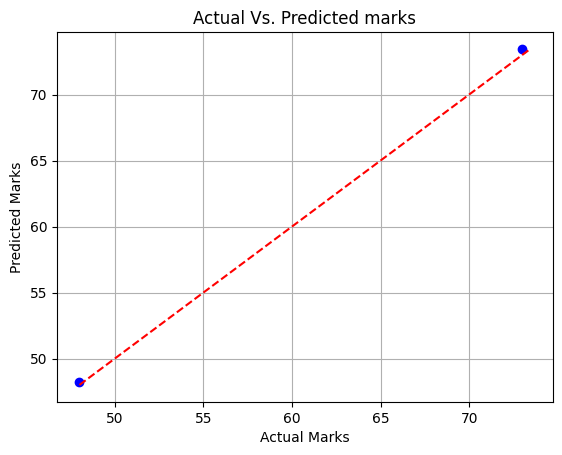

In [16]:
import matplotlib.pyplot as plt

y_test_pred = model.predict(x_test)

plt.scatter(y_test, y_test_pred, color = "blue")

minimum = min(y_test.min(), y_test_pred.min())
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()


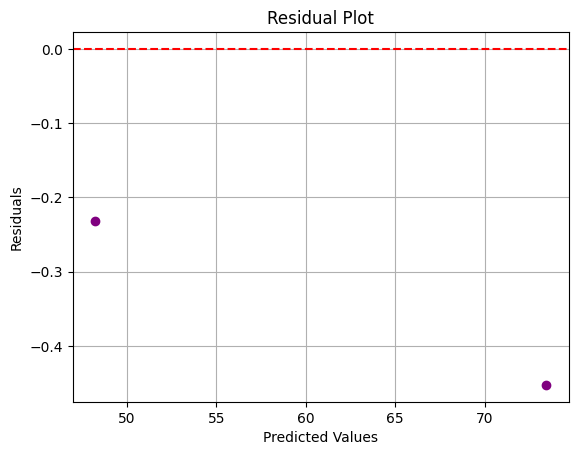

In [18]:
import matplotlib.pyplot as plt

y_test_pred = model.predict(x_test)

residuals = y_test - y_test_pred

plt.scatter(y_test_pred, residuals, color = "purple")
plt.axhline(y = 0, color = "red", linestyle = "--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


After Applying Ridge

In [19]:
from sklearn.linear_model import RidgeCV, Ridge, LassoCV, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas = [0.01, 0.1, 1, 10, 100])
)

model.fit(x, y)

ridge_model = model.named_steps["ridgecv"]
print("Best alpha : ", ridge_model.alpha_)

Best alpha :  0.01


In [20]:
model = make_pipeline(
    StandardScaler(),
    Ridge(alpha = 0.01)
    )

model.fit(x, y)
y_pred = model.predict(x)

In [21]:
ridge_step = model.named_steps['ridge']

print("Intercept : ", ridge_step.intercept_)
print("Standard coefficients : ", ridge_step.coef_)

Intercept :  64.375
Standard coefficients :  [4.11360571 4.11360571 6.99235303]


In [28]:
model_test = LinearRegression()
model_test.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
y_test_pred = model_test.predict(x_test)

In [30]:
print("MAE       : ", mean_absolute_error(y_test, y_test_pred))
print("MSE       : ", mean_squared_error(y_test, y_test_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R-squared : ", r2_score(y_test, y_test_pred))

MAE       :  0.4866666666666717
MSE       :  0.27955555555556205
RMSE      :  0.5287301349039621
R-squared :  0.9982108444444444


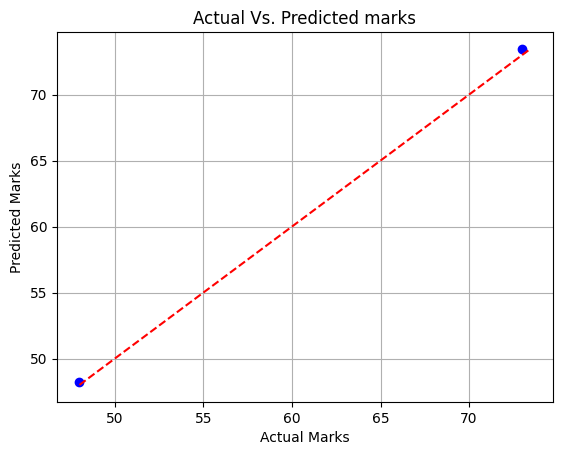

In [31]:
import matplotlib.pyplot as plt

y_test_pred = model.predict(x_test)

plt.scatter(y_test, y_test_pred, color = "blue")

minimum = min(y_test.min(), y_test_pred.min())
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()


After Applying Lasso

In [ ]:
model = make_pipeline(
    StandardScaler(),
    LassoCV(alphas = [0.01, 0.1, 1, 10, 100])
)

model.fit(x, y)

lasso_model = model.named_steps["lassocv"]
print("Best alpha : ", lasso_model.alpha_)

Best alpha :  0.01


In [33]:
model = make_pipeline(
    StandardScaler(),
    Lasso(alpha = 0.01)
    )

model.fit(x, y)
y_pred = model.predict(x)

In [34]:
lasso_step = model.named_steps['lasso']

print("Intercept : ", lasso_step.intercept_)
print("Standard coefficients : ", lasso_step.coef_)

Intercept :  64.375
Standard coefficients :  [7.91119879e+00 5.62050406e-16 7.30569217e+00]


In [27]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

print("MAE       : ", mean_absolute_error(y, y_pred))
print("MSE       : ", mean_squared_error(y, y_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y, y_pred)))
print("R-squared : ", r2_score(y, y_pred))

MAE       :  0.36103114956889026
MSE       :  0.15584790161349313
RMSE      :  0.3947757611777769
R-squared :  0.9993267454807112


In [35]:
model_test = LinearRegression()
model_test.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
y_test_pred = model_test.predict(x_test)

In [37]:
print("MAE       : ", mean_absolute_error(y_test, y_test_pred))
print("MSE       : ", mean_squared_error(y_test, y_test_pred))
print("RMSE      : ", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R-squared : ", r2_score(y_test, y_test_pred))

MAE       :  0.4866666666666717
MSE       :  0.27955555555556205
RMSE      :  0.5287301349039621
R-squared :  0.9982108444444444


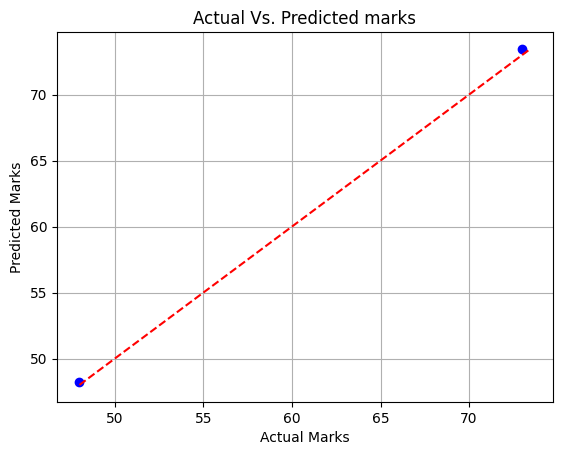

In [38]:
import matplotlib.pyplot as plt

y_test_pred = model.predict(x_test)

plt.scatter(y_test, y_test_pred, color = "blue")

minimum = min(y_test.min(), y_test_pred.min())
maximum = max(y_test.max(), y_test_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color = "red",
    linestyle = "--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual Vs. Predicted marks")
plt.grid(True)
plt.show()
